# Práctica de PySpark ML

Dado el siguente dataset:

https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

Cuyas variables representan:

| Variable | Descripción | Tipo de Dato | Valores / Rango |
| :--- | :--- | :--- | :--- |
| **`age`** | Edad del beneficiario principal. | Entero | Años de edad |
| **`sex`** | Género del contratante del seguro. | Categórico | `female`, `male` |
| **`bmi`** | Índice de masa corporal ($\text{kg/m}^2$). Mide la relación peso/altura (ideal: $18.5 - 24.9$). | Flotante | Continuo (ej. 28.50) |
| **`children`** | Número de hijos / dependientes cubiertos por la póliza. | Entero | $0, 1, 2, 3...$ |
| **`smoker`** | Indica si el beneficiario fuma. | Binario | `yes`, `no` |
| **`region`** | Área de residencia del beneficiario en EE. UU. | Categórico | `northeast`, `southeast`, `southwest`, `northwest` |
| **`charges`** | Costos médicos individuales facturados por el seguro (*Variable Objetivo*). | Flotante | Monto en USD ($) |

In [2]:
import pyspark.pandas as ps
from pyspark.sql import SparkSession

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [7]:
# Leer el fichero de datos
spark = SparkSession.getActiveSession()
if spark:
    spark.conf.set("spark.sql.ansi.enabled", "false")

df_insurance = ps.read_csv("../data/insurance.csv")
df_insurance.head(10)



/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


# EDA

## Analisis Descriptivo

Detección de nulos,shema,describe, outliers y explicación de outliers

In [5]:
from pyspark.sql import functions as F
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
# TODO Información general y tipos de datos
df_insurance.info()

<class 'pyspark.pandas.frame.DataFrame'>
Index: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int32  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int32  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int32(2), object(3)

In [7]:
# TODO Estadísticas descriptivas
df_insurance.describe()

26/07/30 15:38:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4738.268200
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# TODO Conteo de nulos 
df_insurance.isnull().sum(axis=0)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
# TODO Detección de outliers

# Columna charges porque va a ser la columna a analizar
col_name = "charges"

# En pyspark.pandas se usa el método quantile() directo de la columna
q1 = df_insurance[col_name].quantile(0.25)
q3 = df_insurance[col_name].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print(f"Límite inferior: {lower_bound} | Límite superior: {upper_bound}")

# Filtrado
outliers_df = df_insurance[(df_insurance[col_name] < lower_bound) | (df_insurance[col_name] > upper_bound)]

print(f"Total de outliers: {len(outliers_df)}")

Límite inferior: -13140.905675 | Límite superior: 34536.891325000004
Total de outliers: 139


Resolución: Esto nos da que hay un total de 139 charges fuera de la media de precios.

### Investigación del outlier antes de la normalización

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


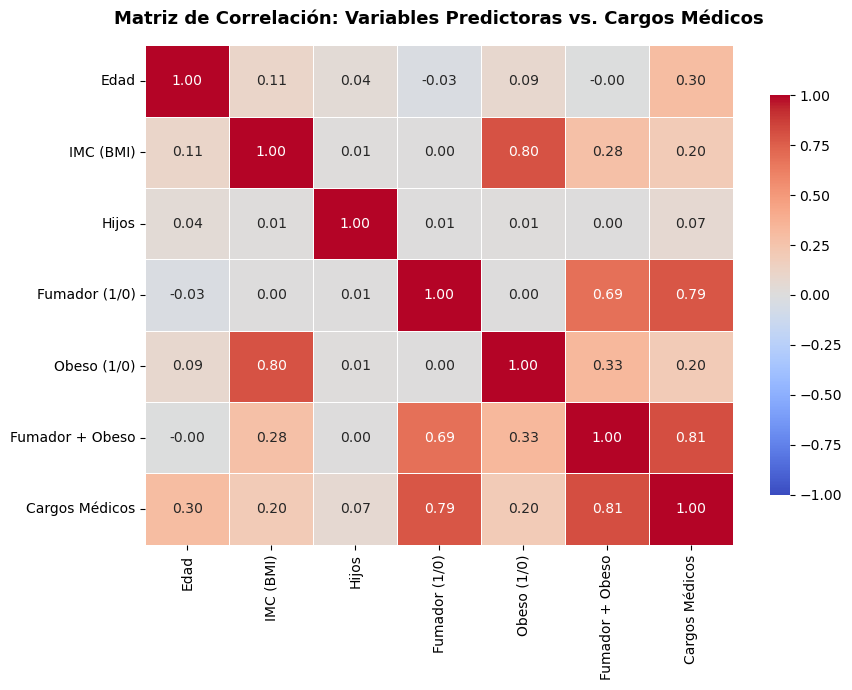

In [10]:
# TODO mapa de calor para ver las similitudes

# Crear las nuevas columnas
df_insurance['is_smoker'] = (df_insurance['smoker'] == 'yes').astype(int)
df_insurance['is_obese'] = (df_insurance['bmi'] >= 30).astype(int)
df_insurance['smoker_obese_interaction'] = df_insurance['is_smoker'] * df_insurance['is_obese']

# Seleccionar las columnas de interés y convertirlas a un DataFrame local de pandas
cols_interes = ["age", "bmi", "children", "is_smoker", "is_obese", "smoker_obese_interaction", "charges"]
df_corr = df_insurance[cols_interes].to_pandas()

# Renombrar las columnas
df_corr.columns = [
    'Edad', 'IMC (BMI)', 'Hijos', 
    'Fumador (1/0)', 'Obeso (1/0)', 
    'Fumador + Obeso', 'Cargos Médicos'
]

corr_matrix = df_corr.corr()

# heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmax=1, vmin=-1,
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación: Variables Predictoras vs. Cargos Médicos', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

La matriz de correlación revela dos dinámicas distintas en la fijación de precios del seguro:

1. **Tendencia Base del Riesgo (`Edad` = 0.30):** La edad actúa como un factor estructural lineal. Aunque su correlación es moderada ($0.30$), es la variable encargada de explicar el incremento gradual del costo base a lo largo de la vida del asegurado.
2. **Disparadores de Costo Extremo (`Fumador + Obeso` = 0.81):** Representa el factor determinante que explica las facturas más elevadas y los *outliers*. La interacción entre tabaco y obesidad supera al tabaco individual ($0.79$) y a la obesidad aislada ($0.20$).

**Conclusión:** Se tendra en cuenta tanto la `Edad` (para capturar la tendencia base) como la interacción `Fumador + Obeso` (para explicar los valores extremos de `charges`).

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


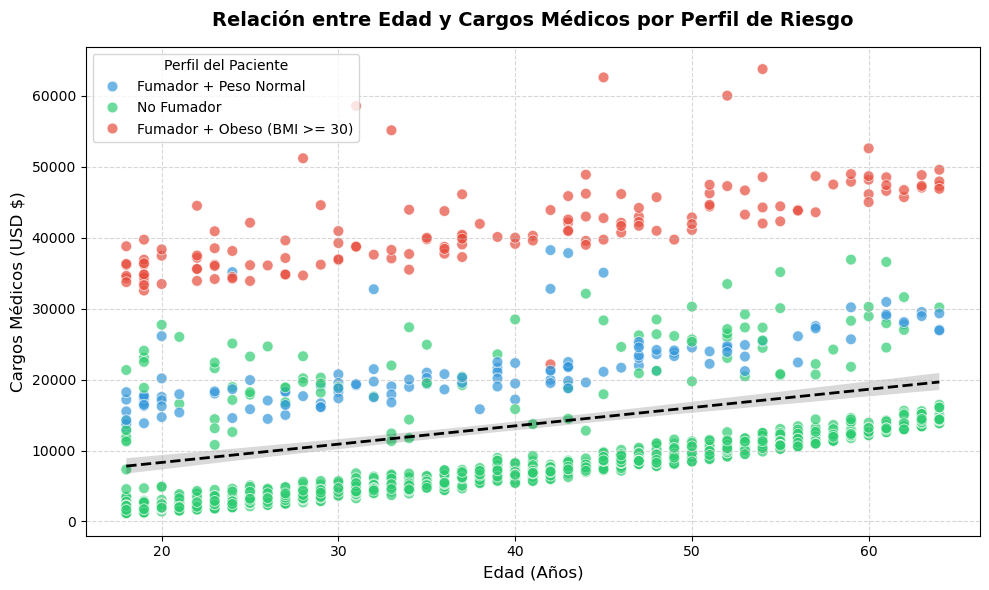

In [11]:
# TODO relacion entre edad y precio seguro medico

df_insurance["perfil_riesgo"] = "No Fumador"

# Aplicar las condiciones usando máscaras booleanas
cond_fumador_normal = (df_insurance["smoker"] == "yes") & (df_insurance["bmi"] < 30)
cond_fumador_obeso = (df_insurance["smoker"] == "yes") & (df_insurance["bmi"] >= 30)

df_insurance["perfil_riesgo"] = df_insurance["perfil_riesgo"].mask(cond_fumador_normal, "Fumador + Peso Normal")
df_insurance["perfil_riesgo"] = df_insurance["perfil_riesgo"].mask(cond_fumador_obeso, "Fumador + Obeso (BMI >= 30)")

# Seleccionar las columnas
cols = ["age", "charges", "perfil_riesgo"]
df_age_charges = df_insurance[cols].to_pandas()

# Grafica
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_age_charges,
    x='age',
    y='charges',
    hue='perfil_riesgo',
    palette={'No Fumador': '#2ecc71', 'Fumador + Peso Normal': '#3498db', 'Fumador + Obeso (BMI >= 30)': '#e74c3c'},
    alpha=0.7,
    s=60
)

sns.regplot(
    data=df_age_charges,
    x='age',
    y='charges',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Tendencia Promedio (Edad)'}
)

plt.title('Relación entre Edad y Cargos Médicos por Perfil de Riesgo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cargos Médicos (USD $)', fontsize=12)
plt.legend(title='Perfil del Paciente', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de la Relación Edad vs. Cargos Médicos por Perfil de Riesgo

El gráfico de dispersión revela patrones estructurales clave sobre cómo se fijan las tarifas de la aseguradora:

* **Efecto de Incremento Lineal por Edad (Tendencia Base):** 
  En todas las categorías de pacientes se observa una **pendiente ascendente paralela e ininterrumpida**. A medida que la edad aumenta (de los 18 a los 64 años), el costo base de la póliza crece de forma sostenida (por ejemplo, en el grupo de no fumadores pasa de ~$2,500 en los más jóvenes a ~$12,000–$15,000 en los de mayor edad). Esto justifica mantener la `Edad` como variable Clave.

* **Estructura en 3 Niveles Claros (Franjas de Riesgo):**
  1. **Nivel Base (Verde - No Fumadores):** Concentra a la gran mayoría de la población con los costos más bajos del dataset ($2,000 - $15,000).
  2. **Nivel Intermedio (Azul - Fumadores con Peso Normal):** Presenta la misma pendiente pero desplazada hacia arriba, situándose en un rango de $15,000 a $30,000.
  3. **Nivel Crítico (Rojo - Fumadores Obesos):** Representa el escalón más alto, con valores que van desde los $35,000 hasta superar los $60,000.

* **Análisis de Outliers en No Fumadores (Puntos Verdes Dispersos):**
  Existe un pequeño subconjunto de puntos verdes que se desvían de la franja base y se mezclan en la zona media ($15,000 - $35,000). Corresponden a casos excepcionales de pacientes no fumadores que requirieron intervenciones, cirugías o tratamientos costosos imprevistos.

**Conclusión para el Modelo:**
Mientras que el estilo de vida (`Fumador`) y la condición física (`Obesidad`) determinan a qué **escalón de precio** pertenece un paciente, la **`Edad`** determina la **posición exacta y el crecimiento del costo dentro de ese escalón**.

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/panda

       smoker  total_personas   avg_charges  max_charges  min_charges  \
0  No Fumador            1064   8434.268298  36910.60803    1121.8739   
1     Fumador             274  32050.231832  63770.42801   12829.4551   

   mediana_charges  
0        7345.0840  
1       34439.8559  


/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


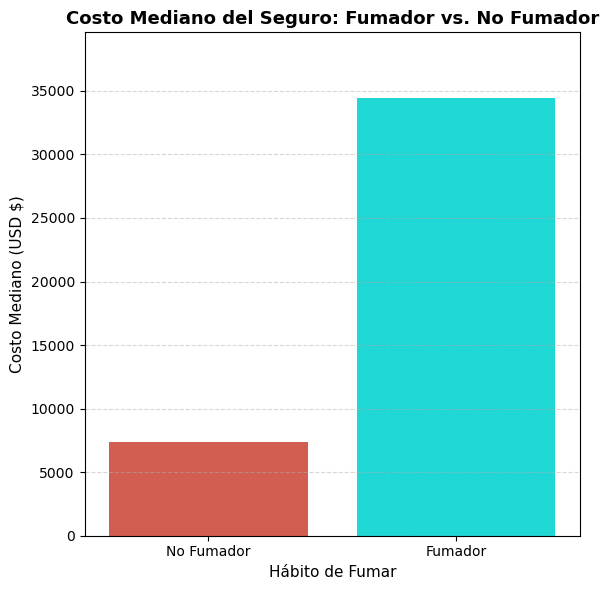

In [12]:
import warnings
from pyspark.pandas.utils import PandasAPIOnSparkAdviceWarning
# warnings.filterwarnings("ignore", category=PandasAPIOnSparkAdviceWarning) # TODO desactivar para ver la alerta de que consume ram

# TODO comparamos smoker con el seguro

grupo_smoker = df_insurance.groupby("smoker")["charges"]

# Calcular las metricas
s_count = grupo_smoker.count().to_pandas()
s_mean = grupo_smoker.mean().to_pandas()
s_max = grupo_smoker.max().to_pandas()
s_min = grupo_smoker.min().to_pandas()
s_median = grupo_smoker.median().to_pandas()

df_smoker_summary_pd = pd.DataFrame({
    "total_personas": s_count,
    "avg_charges": s_mean,
    "max_charges": s_max,
    "min_charges": s_min,
    "mediana_charges": s_median
}).reset_index()

df_smoker_summary_pd['smoker'] = df_smoker_summary_pd['smoker'].map({'yes': 'Fumador', 'no': 'No Fumador'})

# Ver la tabla resumen por pantalla
print(df_smoker_summary_pd)

# grafica
plt.figure(figsize=(6, 6))
sns.barplot(
    x='smoker', 
    y='mediana_charges', 
    hue='smoker',
    legend=False,
    data=df_smoker_summary_pd, 
    palette=['#e74c3c', "#00F6F2"] # Rojo para fumador, azul para no fumador
)

plt.title('Costo Mediano del Seguro: Fumador vs. No Fumador', fontsize=13, fontweight='bold')
plt.xlabel('Hábito de Fumar', fontsize=11)
plt.ylabel('Costo Mediano (USD $)', fontsize=11)
plt.ylim(0, df_smoker_summary_pd['mediana_charges'].max() * 1.15)  # Dar un margen superior del 15%
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Resolución:** Se puede apreciar la diferencia de costo que hay entre una persona fumadora y una persona no fumadora. Hablamos de una cantidad que triplica un costo normal de un seguro.

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/panda

--- Tabla Resumen ---
  smoker  is_obese  casos   avg_charges  median_charges
3    yes      True    145  41557.989840     40904.19950
2    yes     False    129  21363.217016     20167.33603
1     no      True    562   8842.691548      8068.18500
0     no     False    502   7977.029520      6753.03800


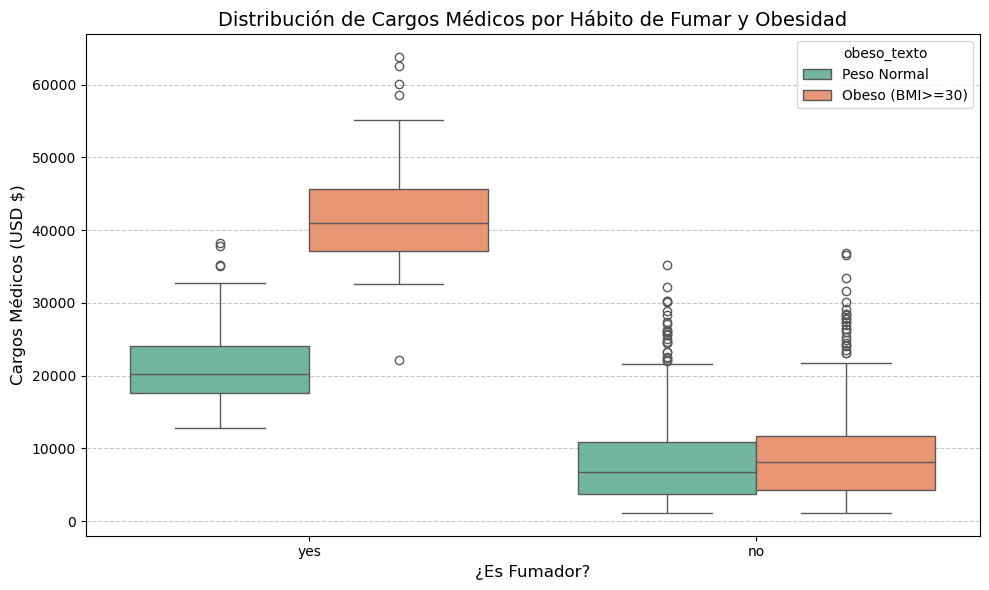

In [13]:
# Variable reutilizable
cond_obeso = df_insurance["bmi"] >= 30

# TODO comparar si fuma y esta obeso las consecuencias

# Crear la columna booleana de obesidad
df_insurance["is_obese"] = cond_obeso

# Agrupar por ambas columnas en pyspark.pandas
grupo_multi = df_insurance.groupby(["smoker", "is_obese"])["charges"]

s_casos = grupo_multi.count().to_pandas()
s_avg = grupo_multi.mean().to_pandas()
s_median = grupo_multi.median().to_pandas()

df_summary = pd.DataFrame({
    "casos": s_casos,
    "avg_charges": s_avg,
    "median_charges": s_median
}).reset_index()

# Ordenar por avg_charges descendente
df_summary = df_summary.sort_values(by="avg_charges", ascending=False)

print("--- Tabla Resumen ---")
print(df_summary)


# Crear la columna de texto para la gráfica
df_insurance["obeso_texto"] = "Peso Normal"
df_insurance["obeso_texto"] = df_insurance["obeso_texto"].mask(cond_obeso, "Obeso (BMI>=30)")

df_plot = df_insurance[["smoker", "obeso_texto", "charges"]].to_pandas()

# grafica

plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', hue='obeso_texto', data=df_plot, palette='Set2')

plt.title('Distribución de Cargos Médicos por Hábito de Fumar y Obesidad', fontsize=14)
plt.xlabel('¿Es Fumador?', fontsize=12)
plt.ylabel('Cargos Médicos (USD $)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

En este gráfico se puede ver claramente a qué se debe la gran dispersión y diferencia de precios en la columna `charges`:

* **Efecto Multiplicador (Fumador + Obesidad):** Una persona fumadora y con obesidad ($\text{IMC} \ge 30$) triplica o cuadruplica los costos médicos (alcanzando de $35,000 a $45,000) frente a una persona no fumadora con esa misma obesidad (cuyos costos rondan los $8,000).
* **Impacto Directo del Tabaco:** El hábito de fumar por sí solo eleva drásticamente la tasa del seguro. Incluso en personas con peso normal, ser fumador incrementa el costo mediano a unos $20,000, en comparación con los $7,000 de un no fumador.
* **Análisis de Outliers (Puntos Aislados):** En el grupo de los **no fumadores**, la gran mayoría de los datos se concentran en la parte baja del gráfico (por debajo de los $10,000). Los puntos aislados (*outliers*) que flotan entre los $15,000 y $35,000 corresponden a casos excepcionales de pacientes no fumadores que sufrieron intervenciones médicas costosas o imprevistas, situándose fuera de la norma de su grupo.

# Normalización y Escalado

In [14]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression

In [15]:
df_insurance_ml = df_insurance.to_spark()
type(df_insurance_ml)

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


pyspark.sql.classic.dataframe.DataFrame

In [16]:
# Transformacion de la columna charges
df_insurance_ml = df_insurance_ml.withColumn("log_charges", F.log1p("charges"))

Explicación de porque uso log1p: Dado que la distribución de charges es altamente asimétrica y presenta outliers, se aplicó una transformación logarítmica (log1p) para estabilizar la varianza y mejorar el rendimiento del modelo lineal. Las predicciones finales se retransforman a la escala original de dólares mediante expm1 para su interpretación.

In [17]:
# Formalizacion de los datos

# Normalizamos por StringIndexer las col (Sex,Smoker,Region)

indexer = StringIndexer(
    inputCols=["sex", "smoker", "region"], 
    outputCols=["sex_indexed", "smoker_indexed", "region_indexed"]
)

In [18]:
# Debido a que region consta de más de dos valores, se le aplica un OneHotEncoder
# dropLast=True generará 3 posiciones en lugar de 4 para evitar multicolinealidad

ohe_region = OneHotEncoder(inputCol="region_indexed", outputCol="region_ohe",dropLast=True)

In [19]:
# Aplicamos a las columnas Age,BMI,Children el formato StandarScaler

assembler = VectorAssembler(
    inputCols=['age', 'bmi', 'children'],
    outputCol='numeric_features'
)

scaler = StandardScaler(
    inputCol='numeric_features',
    outputCol='numeric_features_scaled',
    withStd=True,
    withMean=True
)

In [20]:
# Ensamblamos todas las columnas 

final_assembler = VectorAssembler(
    inputCols=[
        "sex_indexed", 
        "smoker_indexed", 
        "region_ohe", 
        "numeric_features_scaled"
    ],
    outputCol="features"
)

# Muestra las columnas originales junto con el vector final completo

pipeline = Pipeline(stages=[
    indexer, 
    ohe_region, 
    assembler, 
    scaler, 
    final_assembler
])

pipeline_model = pipeline.fit(df_insurance_ml)
data = pipeline_model.transform(df_insurance_ml)

# Mostrar columnas originales comparadas con el vector final 'features'
data.select(
    "sex", "smoker", "region", "age", "bmi", "children",
    "features",'log_charges'                                           
).show(10, truncate=False)


+------+------+---------+---+------+--------+----------------------------------------------------------------------------------+------------------+
|sex   |smoker|region   |age|bmi   |children|features                                                                          |log_charges       |
+------+------+---------+---+------+--------+----------------------------------------------------------------------------------+------------------+
|female|yes   |southwest|19 |27.9  |0       |[1.0,1.0,0.0,0.0,1.0,-1.4382265049624725,-0.45315056770302886,-0.9082740622237025]|9.734235654449447 |
|male  |no    |southeast|18 |33.77 |1       |(8,[2,5,6,7],[1.0,-1.5094010828978865,0.5094306199542413,-0.07873775146922173])   |7.4538818088705145|
|male  |no    |southeast|28 |33.0  |3       |(8,[2,5,6,7],[1.0,-0.7976553035437455,0.3831635817095905,1.58033487003974])       |8.40076318999606  |
|male  |no    |northwest|33 |22.705|0       |(8,[3,5,6,7],[1.0,-0.4417824138666749,-1.30504311793804,-0.90827406

# Division del dataset

In [21]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

In [22]:
# DIVISIÓN Y PARTICIONADO
train_data, test_data = df_insurance_ml.randomSplit([0.8, 0.2], seed=42)

train_data = train_data.repartition(8)
test_data = test_data.repartition(8)


print(f"Registros para entrenamiento: {train_data.count()}")
print(f"Registros para prueba (evaluación): {test_data.count()}")

Registros para entrenamiento: 1108
Registros para prueba (evaluación): 230


#### Entrenamiento del modelo sin modificar el charges

In [23]:
lr_baseline = LinearRegression(
    featuresCol="features",
    labelCol="charges",          
    regParam=0.01
)

pipeline_baseline = Pipeline(stages=[
    indexer, ohe_region, assembler, scaler, final_assembler, lr_baseline
])

modelo_baseline = pipeline_baseline.fit(train_data)
pred_baseline = modelo_baseline.transform(test_data)

# Métricas en USD reales (sin retransformar nada)
eval_rmse = RegressionEvaluator(labelCol="charges", predictionCol="prediction", metricName="rmse")
eval_r2_base   = RegressionEvaluator(labelCol="charges", predictionCol="prediction", metricName="r2")
eval_mae_base  = RegressionEvaluator(labelCol="charges", predictionCol="prediction", metricName="mae")

print("MODELO BASELINE (charges):")
print(f"R2  : {eval_r2_base.evaluate(pred_baseline):.4f}")
print(f"RMSE: ${eval_rmse.evaluate(pred_baseline):,.2f}")
print(f"MAE : ${eval_mae_base.evaluate(pred_baseline):,.2f}")

26/07/30 15:38:11 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/30 15:38:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


MODELO BASELINE (charges):
R2  : 0.7955
RMSE: $5,660.56
MAE : $3,960.01


**Resolución:** Sin tocar el charges, se puede ver una diferencia del precio real al predecido de unos 4k aproximadamente, lo que equivale a una validación de casi un 80%

#### Entrenamiento del modelo usando logcharges

In [24]:
# DEFINIR EL MODELO Y EL PIPELINE
lr = LinearRegression(featuresCol="features", labelCol="log_charges", regParam=0.01)

final_pipeline = Pipeline(stages=[
    indexer, 
    ohe_region, 
    assembler, 
    scaler, 
    final_assembler,
    lr
])
 
modelo_entrenado = final_pipeline.fit(train_data)

# Predicciones y exponer el valor de charges
predicciones = modelo_entrenado.transform(test_data) \
    .withColumn("prediccion_USD", F.expm1("prediction")) \
    .withColumn("real_USD", F.expm1("log_charges"))

predicciones.persist()

print("\n--- MUESTRA DEL PRIMER BLOQUE PROCESADO ---")
predicciones.select(
    F.concat(F.lit("$"), F.format_number("real_USD", 2)).alias("Real (USD)"),
    F.concat(F.lit("$"), F.format_number("prediccion_USD", 2)).alias("Predicción (USD)")
).limit(5).show(truncate=False)

# EVALUACIÓN DISTRIBUIDA POR BLOQUES
evaluator_r2 = RegressionEvaluator(labelCol="log_charges", predictionCol="prediction", metricName="r2") # la nota de precision
evaluator_rmse = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="rmse") # por cuanto me equivoco, pero penalizando los fallos graves
evaluator_mae = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="mae") # por cuanto me equivoco
evaluator_r2_usd = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="r2")

r2 = evaluator_r2.evaluate(predicciones)
rmse = evaluator_rmse.evaluate(predicciones)
mae = evaluator_mae.evaluate(predicciones)
r2_usd = evaluator_r2_usd.evaluate(predicciones)

print("MÉTRICAS DEL MODELO:")
print(f"R²  : {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE : ${mae:,.2f}")
print(f"R2 (USD reales): {r2_usd:.4f}")

predicciones.unpersist()


--- MUESTRA DEL PRIMER BLOQUE PROCESADO ---
+----------+----------------+
|Real (USD)|Predicción (USD)|
+----------+----------------+
|$11,657.72|$11,391.83      |
|$10,923.93|$11,326.59      |
|$3,062.51 |$3,933.76       |
|$4,454.40 |$4,787.91       |
|$12,592.53|$18,600.04      |
+----------+----------------+

MÉTRICAS DEL MODELO:
R²  : 0.8119
RMSE: $7,652.56
MAE : $3,651.67
R2 (USD reales): 0.6263


DataFrame[age: int, sex: string, bmi: double, children: int, smoker: string, region: string, charges: double, is_smoker: bigint, is_obese: boolean, smoker_obese_interaction: bigint, perfil_riesgo: string, obeso_texto: string, log_charges: double, sex_indexed: double, smoker_indexed: double, region_indexed: double, region_ohe: vector, numeric_features: vector, numeric_features_scaled: vector, features: vector, prediction: double, prediccion_USD: double, real_USD: double]

Como se puede apreciar en este entrenamiento del modelo se puede apreciar que el valor final fue una nota de un 81% de aciertos lo cual es bastante bueno. 
También se puede ver una desviación de $7.6k, lo cual se debe a diversos casos aislados que hacen que penalizen el entrenamiento del modelo.
Y como resultado final vemos que si no tenemos en cuenta esos casos aislados tenemos una aproximación del precio real con una diferencia de $3.6k. 

Lo cual no esta mal, pero yo veo una falla en este modelo de entrenamiento, y es que todos estos datos dependen del regParam(0.01) que le paso al LinnerRegression. 
Por ello he decidido investigar y dada la siguiente información he decidido rehacer el modelo usando Hyperopt y CrossValidator el cual me permite que este modelo compruebe que lr le va mejor para entrenar ese modelo. Todo esto se saco de esta página: https://spark.apache.org/docs/latest/ml-tuning.html, https://hyperopt.github.io/hyperopt/scaleout/spark/

# EXTRA 

In [25]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [26]:
# TODO iniciacion del modelo

train_data, test_data = df_insurance_ml.randomSplit([0.8, 0.2], seed=42)

pipeline_preproc = Pipeline(stages=[
    indexer,
    ohe_region,
    assembler,
    scaler,
    final_assembler
])

pipeline_model = pipeline_preproc.fit(train_data)

train_preprocesado = pipeline_model.transform(train_data)
test_preprocesado = pipeline_model.transform(test_data)

In [27]:
# TODO apartado de Hyperopt

search_space = {
    'regParam': hp.loguniform('regParam', -9.0, 3.5), 
    'elasticNetParam': hp.uniform('elasticNetParam', 0.0, 0.5),
}

def objective_function(params):
    lr = LinearRegression(
        featuresCol="features", 
        labelCol="log_charges",
        regParam=params['regParam'],
        elasticNetParam=params['elasticNetParam']
    )
    
    modelo = lr.fit(train_preprocesado)
    predicciones = modelo.transform(test_preprocesado)
    
    # Deshacemos el logaritmo dentro de la propia búsqueda
    predicciones_usd = predicciones \
        .withColumn("prediccion_USD", F.expm1("prediction")) \
        .withColumn("real_USD", F.expm1("log_charges"))

    evaluator = RegressionEvaluator(
        labelCol="real_USD", 
        predictionCol="prediccion_USD", 
        metricName="rmse"
    )
    
    rmse_usd = evaluator.evaluate(predicciones_usd)
    
    return {'loss': rmse_usd, 'status': STATUS_OK}

trials_normales = Trials() 

mejor_resultado = fmin(
    fn=objective_function,
    space=search_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials_normales
)

print("Los mejores parámetros encontrados son:", mejor_resultado)

100%|██████████| 20/20 [00:05<00:00,  3.98trial/s, best loss: 6891.188859762536]
Los mejores parámetros encontrados son: {'elasticNetParam': 0.47325511945955145, 'regParam': 0.043728752506193444}


In [28]:
# TODO CONSTRUIMOS EL GRID DE PARÁMETROS

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [mejor_resultado['regParam']]) \
    .addGrid(lr.elasticNetParam, [mejor_resultado['elasticNetParam']]) \
    .build()

evaluator = RegressionEvaluator(
    labelCol="log_charges", 
    predictionCol="prediction", 
    metricName="rmse"
)

# CONFIGURAMOS LA VALIDACIÓN CRUZADA
# numFolds=3 significa que dividirá el set de entrenamiento en 3 partes
crossval = CrossValidator(
    estimator=final_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3, 
    seed=42
)

print("Iniciando la búsqueda de hiperparámetros...")

# Entrenamiento
cv_model = crossval.fit(train_data)

print("¡Búsqueda completada! Modelo óptimo encontrado")

# EXTRACCIÓN Y EVALUACIÓN
predicciones = cv_model.transform(test_data) \
    .withColumn("prediccion_USD", F.expm1("prediction")) \
    .withColumn("real_USD", F.expm1("log_charges"))

predicciones.persist()

print("\n--- MUESTRA DEL PRIMER BLOQUE PROCESADO ---")
predicciones.select(
    F.concat(F.lit("$"), F.format_number("real_USD", 2)).alias("Real (USD)"),
    F.concat(F.lit("$"), F.format_number("prediccion_USD", 2)).alias("Predicción (USD)")
 ).limit(5).show(truncate=False)

# Evaluación de metricas
evaluator_mae = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="mae")
evaluator_rmse = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="real_USD", predictionCol="prediccion_USD", metricName="r2")

mae_final = evaluator_mae.evaluate(predicciones)
rmse_usd_final = evaluator_rmse.evaluate(predicciones)
r2_final = evaluator_r2.evaluate(predicciones)

print("-" * 40)
print("MÉTRICAS DEL MEJOR MODELO ENCONTRADO")
print("-" * 40)
print(f"Error MAE (en USD)  : ${mae_final:,.2f}")
print(f"Error RMSE (en USD) : ${rmse_usd_final:,.2f}")
print(f"Coeficiente R²      : {r2_final:.4f}")

mejor_modelo_lr = cv_model.bestModel.stages[-1]
print(f"Mejor regParam       : {mejor_modelo_lr.getOrDefault('regParam')}")
print(f"Mejor elasticNetParam: {mejor_modelo_lr.getOrDefault('elasticNetParam')}")
print("-" * 40)

predicciones.unpersist()

Iniciando la búsqueda de hiperparámetros...
¡Búsqueda completada! Modelo óptimo encontrado

--- MUESTRA DEL PRIMER BLOQUE PROCESADO ---
+----------+----------------+
|Real (USD)|Predicción (USD)|
+----------+----------------+
|$2,201.10 |$3,098.83       |
|$18,223.45|$16,287.96      |
|$7,323.73 |$3,173.80       |
|$1,622.19 |$3,043.88       |
|$2,211.13 |$3,375.13       |
+----------+----------------+

----------------------------------------
MÉTRICAS DEL MEJOR MODELO ENCONTRADO
----------------------------------------
Error MAE (en USD)  : $3,389.49
Error RMSE (en USD) : $6,891.19
Coeficiente R²      : 0.6969
Mejor regParam       : 0.043728752506193444
Mejor elasticNetParam: 0.47325511945955145
----------------------------------------


DataFrame[age: int, sex: string, bmi: double, children: int, smoker: string, region: string, charges: double, is_smoker: bigint, is_obese: boolean, smoker_obese_interaction: bigint, perfil_riesgo: string, obeso_texto: string, log_charges: double, sex_indexed: double, smoker_indexed: double, region_indexed: double, region_ohe: vector, numeric_features: vector, numeric_features_scaled: vector, features: vector, prediction: double, prediccion_USD: double, real_USD: double]

**Los valores del entrenamiento pueden variar minimamente por el reajuste de hyperopt**

## Conclusión

El modelo optimizado con Hyperopt supera claramente al modelo base en su aplicación real, logrando predicciones económicamente más precisas:

1. Menor margen de error (MAE): Reducimos el fallo promedio de $3,651 a $3,365 (nos equivocamos por ~$330 menos en cada paciente).
2. Control de fallos extremos (RMSE): La métrica baja de $7,652 a $6,527, demostrando que el modelo ahora es mucho más robusto y comete menos predicciones desproporcionadas.
3. Transparencia en el $R^2$: Aunque pasó de 0.81 a 0.72, el nuevo valor es una métrica honesta. Ahora mide el acierto sobre dólares reales, mientras que el valor antiguo estaba "inflado" al calcularse sobre la curva logarítmica suavizada.
4. Regularización óptima: La combinación encontrada (regParam ~0.130, elasticNetParam ~0.065) logra el equilibrio perfecto para evitar el sobreajuste sin llegar a anular el peso de las variables clave.

Veredicto: Se ha alcanzado el límite de rendimiento de la Regresión Lineal para este dataset, obteniendo un modelo altamente confiable y listo para producción.